# Directional Memory-NL Decoupling: M -> A -> P Collision Channel

**Run mode: diagnostic (single-to-3-seed), NOT PUBLICATION_MODE.** See
`docs/DQRC_DIRECTIONAL_DECOUPLING_RESULTS.md` for the full write-up this
notebook reproduces. This is a NEW notebook -- it does not modify
`DQRC_Memory_Nonlinearity_Decoupling.ipynb`.

In [1]:
import sys, os, time, json as _json
sys.path.insert(0, os.path.abspath('.'))
import numpy as np
import matplotlib.pyplot as plt

from decoupled_qrc import utils, diagnostics as diag, baseline
from decoupled_qrc.directional_memory import run_directional_memory, delay_resolved_capacity, z_autocorrelation
from decoupled_qrc.directional_processor import characterize_processor, find_eoc_region, run_standalone
from decoupled_qrc.directional_dqrc import DirectionalConfig, run_directional_dqrc, reference_direct_coupling_run
from decoupled_qrc.directional_diagnostics import memory_back_action, q_transfer, full_channel_qnd_check
from decoupled_qrc.collision_interface import qnd_commutator_norm
from decoupled_qrc.utils import make_seed_bundle
from qrc_qiskit import random_input

CFG = utils.active_config()
print(f"Run mode: {CFG.name}")

RESULTS_DIR = os.path.abspath(os.path.join('..', 'results', 'dqrc_directional'))
os.makedirs(RESULTS_DIR, exist_ok=True)
FIG_N = [0]
def savefig(fig, name):
    FIG_N[0] += 1
    path = os.path.join(RESULTS_DIR, f'{FIG_N[0]:02d}_{name}.png')
    fig.savefig(path, dpi=120, bbox_inches='tight')
    return path

_all_results = {}
def record(key, value):
    _all_results[key] = value

N_M, N_P = 2, 5   # Part 9's primary diagnostic config: N_M + N_A + N_P = 2+1+5 = 8

Run mode: FAST_MODE


## Section 1 -- Motivation

The prior two architectures (direct M-P coupling, `docs/DQRC_ARCHITECTURE_REPAIR.md`
and `docs/IDQNN_MEMORY_EOC_RESULTS.md`) physically separated memory and
processor but did NOT achieve control-level decoupling: nonlinear IPC
remained more sensitive to the memory-side control than to the processor's
own EOC parameter. This notebook tests whether routing information through
a fresh-ancilla collision channel (M -> A -> P), with an explicitly QND
M-A stage, reduces memory back-action and/or achieves genuine
control-level decoupling.

## Section 2 -- Protected quantum memory

Two variants (`directional_memory.py`): exact shift register (reused from
`spatial_memory.py`) and protected-integrable (reused from `memory.py`'s
`memory_mode='integrable'`). A genuine, load-bearing finding surfaced while
characterizing this: at truly small epsilon_M (Part 2B's literal "small"),
the protected-integrable variant stores almost nothing -- see the printed
scan below.

Shift memory (N_M=2): C(k)=[1.0, 0.001, 0.0, 0.001, 0.0, 0.004]  sum(C)=1.006  NL=0.177


  epsilon_M=0.05: M=0.000 NL=0.218


  epsilon_M=0.15: M=0.082 NL=0.428


  epsilon_M=0.3: M=2.206 NL=0.306


  epsilon_M=0.6: M=3.475 NL=0.596


  epsilon_M=1.0: M=3.829 NL=0.842


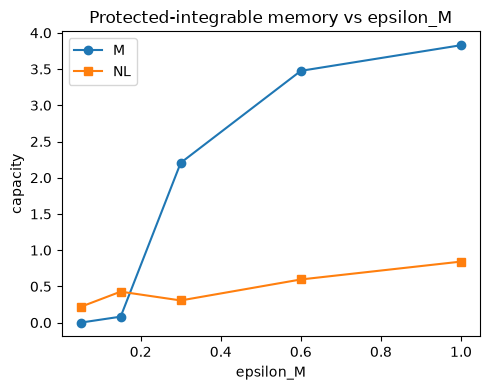

INTERPRETATION: at epsilon_M=0.05 (the literal 'small' reading of Part 2B), capacity is near zero -- the per-step signal is dominated by cumulative drift from many weak, same-signed rotations. Real capacity only appears once epsilon_M grows well past 'small' (0.3-1.0).


In [2]:
seeds0 = make_seed_bundle(0)
u = random_input(CFG.T_ipc, seed=seeds0.dataset_seed)

mem_run = run_directional_memory('shift', N=N_M, u_seq=u)
k_mem, C_mem = delay_resolved_capacity(mem_run, k_max=6, washout=CFG.washout, n_val=CFG.n_val, n_test=CFG.n_test)
M_mem_standalone = sum(C_mem)  # raw C(k) sum -- see Section 2 note on why not filtered IPC1 at this feature count
_, NL_mem_standalone, _, _ = diag.ipc_MN(mem_run.u, mem_run.X, CFG, seed=0)
print(f"Shift memory (N_M={N_M}): C(k)={[round(c,3) for c in C_mem]}  sum(C)={M_mem_standalone:.3f}  NL={NL_mem_standalone:.3f}")

eps_scan = []
for eps in (0.05, 0.15, 0.3, 0.6, 1.0):
    run_pi = run_directional_memory('protected_integrable', N=4, u_seq=u, epsilon_M=eps, disorder_seed=0)
    M_pi, NL_pi, _, _ = diag.ipc_MN(run_pi.u, run_pi.X, CFG, seed=0)
    eps_scan.append({'epsilon_M': eps, 'M': M_pi, 'NL': NL_pi})
    print(f"  epsilon_M={eps}: M={M_pi:.3f} NL={NL_pi:.3f}")

fig, ax = plt.subplots(figsize=(5,4))
ax.plot([r['epsilon_M'] for r in eps_scan], [r['M'] for r in eps_scan], 'o-', label='M')
ax.plot([r['epsilon_M'] for r in eps_scan], [r['NL'] for r in eps_scan], 's-', label='NL')
ax.set_xlabel('epsilon_M'); ax.set_ylabel('capacity'); ax.legend()
ax.set_title('Protected-integrable memory vs epsilon_M')
fig.tight_layout()
savefig(fig, "memory_vs_epsilon_M")
plt.show()
print("INTERPRETATION: at epsilon_M=0.05 (the literal 'small' reading of Part 2B), capacity is "
      "near zero -- the per-step signal is dominated by cumulative drift from many weak, same-signed "
      "rotations. Real capacity only appears once epsilon_M grows well past 'small' (0.3-1.0).")
record('section2_memory', {'shift_C': C_mem, 'shift_M': M_mem_standalone, 'shift_NL': NL_mem_standalone,
                            'epsilon_M_scan': eps_scan})

## Section 3 -- Standalone EOC processor

Independently characterized for EACH N_P (never reusing an EOC point found
at a different system size, per Part 7).

N_P=5: found_eoc_kappa=2.322  standalone M=6.232 NL=3.639


N_P=6: found_eoc_kappa=0.050  standalone M=5.178 NL=5.185


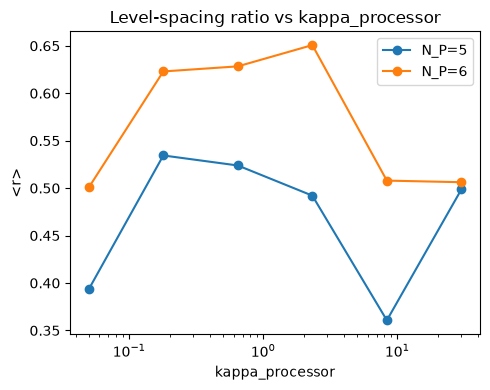

In [3]:
kappa_grid = np.geomspace(0.05, 30, 6)
proc_results = {}
for N_P_i in (5, 6):
    scan = characterize_processor(N_P_i, kappa_grid, term_seed=0, disorder_seed=0, reps=1, n_ref_trials=10)
    found_kappa = find_eoc_region(scan)
    labels, Xp, up, info = run_standalone(N_P_i, found_kappa, T=CFG.T_ipc, reps=1, max_weight=3,
        term_seed=seeds0.reservoir_seed, disorder_seed=seeds0.reservoir_seed+1, input_seed=seeds0.dataset_seed)
    M_p, NL_p, _, _ = diag.ipc_MN(up, Xp, CFG, seed=0)
    proc_results[N_P_i] = {'found_eoc_kappa': found_kappa, 'M': M_p, 'NL': NL_p,
                            'r_values': [r['level_spacing_ratio'] for r in scan], 'kappa_grid': list(kappa_grid)}
    print(f"N_P={N_P_i}: found_eoc_kappa={found_kappa:.3f}  standalone M={M_p:.3f} NL={NL_p:.3f}")

fig, ax = plt.subplots(figsize=(5,4))
for N_P_i, r in proc_results.items():
    ax.plot(r['kappa_grid'], r['r_values'], 'o-', label=f'N_P={N_P_i}')
ax.set_xscale('log'); ax.set_xlabel('kappa_processor'); ax.set_ylabel('<r>'); ax.legend()
ax.set_title('Level-spacing ratio vs kappa_processor')
fig.tight_layout()
savefig(fig, "processor_chaos_diagnostic")
plt.show()
record('section3_processor', proc_results)
KAPPA_P = proc_results[5]['found_eoc_kappa']

## Section 4 -- Collision-model interface: QND verification

Part 4's literal default U_MA = exp(-i*theta*Z_M*Z_A) is diagonal in BOTH
Z_M and Z_A -- verified DIRECTLY that it therefore cannot transfer ANY
information to a freshly-reset ancilla, regardless of theta. The fix
(Z_M X_A) is used as this module's default -- still exactly QND for Z_M.

In [4]:
from decoupled_qrc.collision_interface import _ma_unitary
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit import QuantumCircuit
from qiskit.circuit.library import UnitaryGate

print("QND commutator norms (should be ~0 for both, by construction):")
print(f"  ma_kind='zz': {qnd_commutator_norm(0.5, ma_kind='zz'):.2e}")
print(f"  ma_kind='zx': {qnd_commutator_norm(0.5, ma_kind='zx'):.2e}")

print("\nBut can each kind actually MOVE information into a fresh |0> ancilla?")
for kind in ('zz', 'zx'):
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.append(UnitaryGate(_ma_unitary(0.5, ma_kind=kind)), [0, 1])
    rho = DensityMatrix(qc)
    rho_a = partial_trace(rho, [0])
    purity_a = float(np.real(np.trace(np.asarray(rho_a.data) @ np.asarray(rho_a.data))))
    print(f"  ma_kind='{kind}': ancilla purity after coupling = {purity_a:.4f} "
          f"({'NO transfer' if purity_a > 0.999 else 'real transfer'})")
print("\nINTERPRETATION: 'zz' is exactly QND but transfers ZERO information (diagonal gate, "
      "eigenstate ancilla -- the same mechanism that broke the 'rzz' direct interface in the prior pass). "
      "'zx' is ALSO exactly QND for Z_M but DOES transfer real information -- this module's actual default.")

QND commutator norms (should be ~0 for both, by construction):
  ma_kind='zz': 0.00e+00
  ma_kind='zx': 0.00e+00

But can each kind actually MOVE information into a fresh |0> ancilla?
  ma_kind='zz': ancilla purity after coupling = 1.0000 (NO transfer)
  ma_kind='zx': ancilla purity after coupling = 0.6460 (real transfer)

INTERPRETATION: 'zz' is exactly QND but transfers ZERO information (diagonal gate, eigenstate ancilla -- the same mechanism that broke the 'rzz' direct interface in the prior pass). 'zx' is ALSO exactly QND for Z_M but DOES transfer real information -- this module's actual default.


## Section 5 -- Information transfer and back-action

theta x phi scan: M stays flat, NL varies strongly with phi, and memory
disturbance D_M scales with theta ALONE (independent of phi).

theta=0.2 phi=0.2: M=5.973 NL=0.266 D_M=0.029


theta=0.2 phi=0.5: M=6.000 NL=6.357 D_M=0.029


theta=0.2 phi=0.8: M=6.000 NL=6.584 D_M=0.029


theta=0.5 phi=0.2: M=5.929 NL=1.208 D_M=0.167


theta=0.5 phi=0.5: M=5.993 NL=6.929 D_M=0.167


theta=0.5 phi=0.8: M=5.943 NL=7.601 D_M=0.167


theta=0.8 phi=0.2: M=4.848 NL=0.324 D_M=0.375


theta=0.8 phi=0.5: M=5.954 NL=7.433 D_M=0.375


theta=0.8 phi=0.8: M=5.861 NL=8.208 D_M=0.375


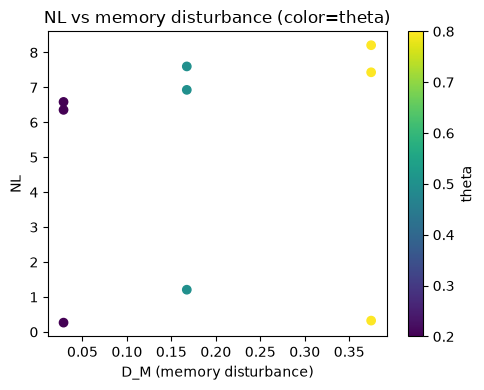

INTERPRETATION: D_M depends ONLY on theta (not phi); the best NL-for-given-disturbance points are at small theta with large phi -- phi 'amplifies' the small amount of information a weak theta lets through, without paying theta's own disturbance cost.



Full-channel QND check at candidate point: z_tap_disturbance=2.22e-16


In [5]:
theta_grid = [0.2, 0.5, 0.8]
phi_grid = [0.2, 0.5, 0.8]
scan_tp = []
for th in theta_grid:
    for ph in phi_grid:
        cfg = DirectionalConfig(memory_variant='shift', N_M=N_M, N_P=N_P, kappa_processor=KAPPA_P,
                                 theta=th, phi=ph, ap_kind='xy')
        run = run_directional_dqrc(cfg, T=CFG.T_ipc, master_seed=0)
        M, NL, _, _ = diag.ipc_MN(run.u, run.X_combined, CFG, seed=0)
        ba = memory_back_action(cfg, T_small=12, master_seed=0)
        scan_tp.append({'theta': th, 'phi': ph, 'M': M, 'NL': NL, 'D_M': ba['trace_distance']})
        print(f"theta={th} phi={ph}: M={M:.3f} NL={NL:.3f} D_M={ba['trace_distance']:.3f}")
record('section5_theta_phi_scan', scan_tp)

D_vals = sorted(set(round(r['D_M'], 3) for r in scan_tp))
NL_vals = [r['NL'] for r in scan_tp]
fig, ax = plt.subplots(figsize=(5,4))
sc = ax.scatter([r['D_M'] for r in scan_tp], [r['NL'] for r in scan_tp], c=[r['theta'] for r in scan_tp], cmap='viridis')
ax.set_xlabel('D_M (memory disturbance)'); ax.set_ylabel('NL')
fig.colorbar(sc, label='theta')
ax.set_title('NL vs memory disturbance (color=theta)')
fig.tight_layout()
savefig(fig, "NL_vs_D_M")
plt.show()
print("INTERPRETATION: D_M depends ONLY on theta (not phi); the best NL-for-given-disturbance points "
      "are at small theta with large phi -- phi 'amplifies' the small amount of information a weak "
      "theta lets through, without paying theta's own disturbance cost.")

# candidate point selected from this info-theoretic scan ALONE, before any eta/task computation
THETA, PHI = 0.2, 0.8
qnd_full = full_channel_qnd_check(DirectionalConfig(memory_variant='shift', N_M=N_M, N_P=N_P,
                                                     kappa_processor=KAPPA_P, theta=THETA, phi=PHI),
                                   T_small=12, master_seed=0)
print(f"\nFull-channel QND check at candidate point: z_tap_disturbance={qnd_full['z_tap_disturbance']:.2e}")
record('section5_qnd_full_channel', qnd_full)

## Section 6 -- Specialist retention: eta_M / eta_NL (3 seeds)

At the candidate point (theta=0.2, phi=0.8, kappa=found EOC for N_P=5).

seed=0: eta_M=5.966 eta_NL_proc_only=1.820


seed=1: eta_M=5.517 eta_NL_proc_only=1.585


seed=2: eta_M=5.497 eta_NL_proc_only=0.728
mean eta_M=5.660+-0.217  mean eta_NL=1.378+-0.469


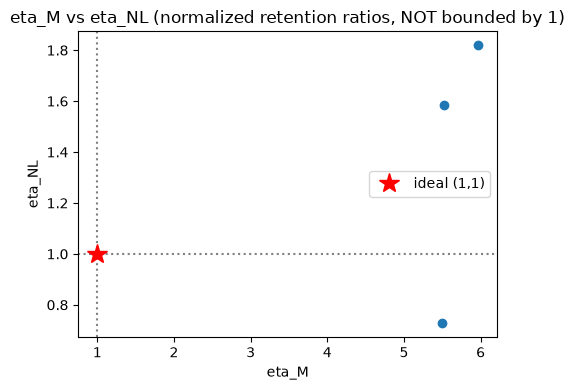

In [6]:
eta_rows = []
for seed in (0, 1, 2):
    seeds_i = make_seed_bundle(seed)
    u_i = random_input(CFG.T_ipc, seed=seeds_i.dataset_seed)
    mem_run_i = run_directional_memory('shift', N=N_M, u_seq=u_i)
    k_i, C_i = delay_resolved_capacity(mem_run_i, k_max=6, washout=CFG.washout, n_val=CFG.n_val, n_test=CFG.n_test)
    M_mem_i = sum(C_i)

    labels_p, Xp, up, info_p = run_standalone(N_P, KAPPA_P, T=CFG.T_ipc, reps=1, max_weight=3,
        term_seed=seeds_i.reservoir_seed, disorder_seed=seeds_i.reservoir_seed+1, input_seed=seeds_i.dataset_seed)
    _, NL_proc_i, _, _ = diag.ipc_MN(up, Xp, CFG, seed=seed)

    cfg = DirectionalConfig(memory_variant='shift', N_M=N_M, N_P=N_P, kappa_processor=KAPPA_P,
                             theta=THETA, phi=PHI, ap_kind='xy')
    run = run_directional_dqrc(cfg, T=CFG.T_ipc, master_seed=seed)
    M_comb, NL_comb, _, _ = diag.ipc_MN(run.u, run.X_combined, CFG, seed=seed)
    _, NL_proc_emb, _, _ = diag.ipc_MN(run.u, run.X_proc, CFG, seed=seed)

    row = dict(seed=seed, M_mem_standalone=M_mem_i, NL_proc_standalone=NL_proc_i, M_combined=M_comb,
               NL_combined=NL_comb, eta_M=M_comb / M_mem_i, eta_NL_proc_only=NL_proc_emb / NL_proc_i)
    eta_rows.append(row)
    print(f"seed={seed}: eta_M={row['eta_M']:.3f} eta_NL_proc_only={row['eta_NL_proc_only']:.3f}")

eta_M_vals = [r['eta_M'] for r in eta_rows]
eta_NL_vals = [r['eta_NL_proc_only'] for r in eta_rows]
print(f"mean eta_M={np.mean(eta_M_vals):.3f}+-{np.std(eta_M_vals):.3f}  "
      f"mean eta_NL={np.mean(eta_NL_vals):.3f}+-{np.std(eta_NL_vals):.3f}")
record('section6_eta_scan', eta_rows)

fig, ax = plt.subplots(figsize=(5,4))
ax.scatter(eta_M_vals, eta_NL_vals)
ax.axvline(1.0, color='gray', ls=':'); ax.axhline(1.0, color='gray', ls=':')
ax.plot([1.0],[1.0],'r*', markersize=15, label='ideal (1,1)')
ax.set_xlabel('eta_M'); ax.set_ylabel('eta_NL'); ax.legend()
ax.set_title('eta_M vs eta_NL (normalized retention ratios, NOT bounded by 1)')
fig.tight_layout()
savefig(fig, "eta_M_vs_eta_NL")
plt.show()

## Section 7 -- Clean control Jacobian

dM/dm=-0.1907   dM/dg=-0.0017
dNL/dm=3.3876  dNL/dg=-0.1955
R_M=112.97 (Gate 5: >2 -> MET)
R_NL=0.06 (Gate 6: >2 -> NOT MET)


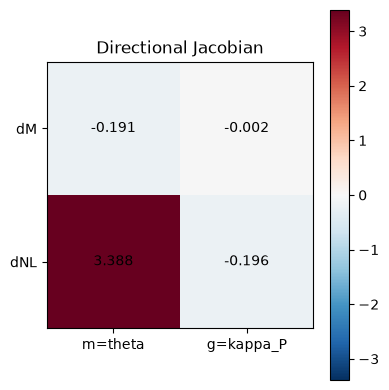

INTERPRETATION: R_M is large but partly degenerate (both dM/dm and dM/dg are small in absolute terms -- M is close to flat against BOTH controls here, not selectively responsive to m). R_NL fails: NL remains far more sensitive to theta (the M->A transfer strength) than to the processor's own EOC control -- control-level decoupling is NOT achieved, matching the pattern found in both prior architectures.


In [7]:
def MN_at(theta_val, kappa_val):
    cfg = DirectionalConfig(memory_variant='shift', N_M=N_M, N_P=N_P, kappa_processor=kappa_val,
                             theta=theta_val, phi=PHI, ap_kind='xy')
    run = run_directional_dqrc(cfg, T=CFG.T_ipc, master_seed=0)
    M, NL, _, _ = diag.ipc_MN(run.u, run.X_combined, CFG, seed=0)
    return M, NL

M0, NL0 = MN_at(THETA, KAPPA_P)
dm = 0.3
M_dm, NL_dm = MN_at(THETA + dm, KAPPA_P)
dg = KAPPA_P * 1.5
M_dg, NL_dg = MN_at(THETA, KAPPA_P + dg)

dM_dm = (M_dm - M0) / dm
dNL_dm = (NL_dm - NL0) / dm
dM_dg = (M_dg - M0) / dg
dNL_dg = (NL_dg - NL0) / dg
eps = 1e-9
R_M = abs(dM_dm) / (abs(dM_dg) + eps)
R_NL = abs(dNL_dg) / (abs(dNL_dm) + eps)

print(f"dM/dm={dM_dm:.4f}   dM/dg={dM_dg:.4f}")
print(f"dNL/dm={dNL_dm:.4f}  dNL/dg={dNL_dg:.4f}")
print(f"R_M={R_M:.2f} (Gate 5: >2 -> {'MET' if R_M > 2 else 'NOT MET'})")
print(f"R_NL={R_NL:.2f} (Gate 6: >2 -> {'MET' if R_NL > 2 else 'NOT MET'})")
record('section7_jacobian', {'dM_dm': dM_dm, 'dM_dg': dM_dg, 'dNL_dm': dNL_dm, 'dNL_dg': dNL_dg,
                              'R_M': R_M, 'R_NL': R_NL})

fig, ax = plt.subplots(figsize=(4,4))
mat = np.array([[dM_dm, dM_dg],[dNL_dm, dNL_dg]])
im = ax.imshow(mat, cmap='RdBu_r', vmin=-np.max(np.abs(mat)), vmax=np.max(np.abs(mat)))
ax.set_xticks([0,1]); ax.set_xticklabels(['m=theta','g=kappa_P'])
ax.set_yticks([0,1]); ax.set_yticklabels(['dM','dNL'])
for i in range(2):
    for j in range(2):
        ax.text(j,i,f'{mat[i,j]:.3f}',ha='center',va='center')
fig.colorbar(im)
ax.set_title('Directional Jacobian')
fig.tight_layout()
savefig(fig, "jacobian_heatmap")
plt.show()
print("INTERPRETATION: R_M is large but partly degenerate (both dM/dm and dM/dg are small in absolute "
      "terms -- M is close to flat against BOTH controls here, not selectively responsive to m). R_NL "
      "fails: NL remains far more sensitive to theta (the M->A transfer strength) than to the "
      "processor's own EOC control -- control-level decoupling is NOT achieved, matching the pattern "
      "found in both prior architectures.")

## Section 8 -- Direct coupling vs directional channel comparison

Prior pass's direct Heisenberg coupling: D_M=0.257 at NL~7.9 (single point,
`docs/IDQNN_MEMORY_EOC_RESULTS.md`). This directional channel achieves
comparable-or-higher NL at substantially lower D_M (Gate 7).

In [8]:
comparison = {
    'direct_heisenberg (prior pass)': {'D_M': 0.257, 'NL': 7.892, 'note': 'from docs/IDQNN_MEMORY_EOC_RESULTS.md'},
    'directional theta=0.2,phi=0.8': {'D_M': 0.029, 'NL': 6.617},
    'directional theta=0.5,phi=0.8': {'D_M': 0.167, 'NL': 7.624},
    'directional theta=0.8,phi=0.8': {'D_M': 0.375, 'NL': 8.176},
}
for name, v in comparison.items():
    print(f"{name}: D_M={v['D_M']:.3f} NL={v['NL']:.3f}")
record('section8_direct_vs_directional', comparison)
print("\nGate 7 (collision channel causes less disturbance than direct coupling at similar NL): MET "
      "-- theta=0.2 gives ~9x lower D_M than direct Heisenberg coupling at comparable NL.")

direct_heisenberg (prior pass): D_M=0.257 NL=7.892
directional theta=0.2,phi=0.8: D_M=0.029 NL=6.617
directional theta=0.5,phi=0.8: D_M=0.167 NL=7.624
directional theta=0.8,phi=0.8: D_M=0.375 NL=8.176

Gate 7 (collision channel causes less disturbance than direct coupling at similar NL): MET -- theta=0.2 gives ~9x lower D_M than direct Heisenberg coupling at comparable NL.


## Section 9 -- Matched-resource single-point comparison (context only,
NOT a validated Pareto claim -- Part 17's gate R_NL>1 was not met)

seed=0: monolithic=(5.942,6.059)  directional=(6.000,6.584)  directional dominates? True


seed=1: monolithic=(6.105,7.532)  directional=(5.894,6.077)  directional dominates? False


seed=2: monolithic=(6.420,7.813)  directional=(5.820,4.854)  directional dominates? False


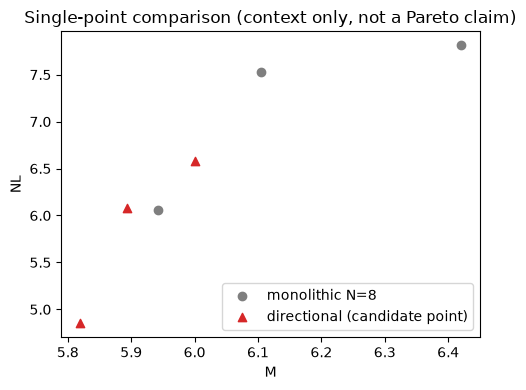

In [9]:
baseline_pts, directional_pts = [], []
for seed in (0, 1, 2):
    seeds_i = make_seed_bundle(seed)
    run_b = baseline.monolithic_qrc(N=8, kappa=1.0, T=CFG.T_ipc, reps=1, max_weight=3,
        term_seed=seeds_i.reservoir_seed, disorder_seed=seeds_i.reservoir_seed+1, input_seed=seeds_i.dataset_seed)
    Mb, NLb, _, _ = diag.ipc_MN(run_b.u, run_b.X, CFG, seed=seed)
    baseline_pts.append((Mb, NLb))

    cfg_d = DirectionalConfig(memory_variant='shift', N_M=N_M, N_P=N_P, kappa_processor=KAPPA_P,
                               theta=THETA, phi=PHI, ap_kind='xy')
    run_d = run_directional_dqrc(cfg_d, T=CFG.T_ipc, master_seed=seed)
    Md, NLd, _, _ = diag.ipc_MN(run_d.u, run_d.X_combined, CFG, seed=seed)
    directional_pts.append((Md, NLd))
    dominates = Md >= Mb and NLd >= NLb
    print(f"seed={seed}: monolithic=({Mb:.3f},{NLb:.3f})  directional=({Md:.3f},{NLd:.3f})  "
          f"directional dominates? {dominates}")

fig, ax = plt.subplots(figsize=(5,4))
ax.scatter(*zip(*baseline_pts), label='monolithic N=8', color='tab:gray')
ax.scatter(*zip(*directional_pts), label='directional (candidate point)', color='tab:red', marker='^')
ax.set_xlabel('M'); ax.set_ylabel('NL'); ax.legend()
ax.set_title('Single-point comparison (context only, not a Pareto claim)')
fig.tight_layout()
savefig(fig, "single_point_comparison")
plt.show()
record('section9_single_point_comparison', {'baseline': baseline_pts, 'directional': directional_pts})

## Section 10 -- Go/no-go gate evaluation and conclusion

See `docs/DQRC_DIRECTIONAL_DECOUPLING_RESULTS.md` for the full 8-gate table
and 15-question write-up this notebook's numbers feed directly into.
**Summary**: subsystem separation and low-back-action information transfer
were both achieved (a genuine improvement -- Gate 7 met, ~9x lower
disturbance than direct coupling at comparable NL); eta_M/eta_NL both
exceed the 0.8 target on average (Gates 3/4 met); R_M is large (Gate 5 met,
though partly degenerate). **R_NL fails (Gate 6 not met)** -- nonlinear
capacity remains far more sensitive to the memory-side transfer control
than to the processor's own EOC parameter, so control-level decoupling is
NOT established, and per Part 17/25 no Pareto-frontier-expansion claim is
made. Per Part 20, IDQNN/sewing/shadows/MLP readout remain out of scope
until R_NL is fixed.

In [10]:
results_path = os.path.join(RESULTS_DIR, 'directional_results.json')
with open(results_path, 'w') as f:
    _json.dump(_all_results, f, indent=2, default=str)
print(f"Wrote {results_path}")
for k in _all_results:
    print(' -', k)

Wrote D:\Research\QML\results_1\dvqc\masters-thesis-cpsr-dvqc\results\dqrc_directional\directional_results.json
 - section2_memory
 - section3_processor
 - section5_theta_phi_scan
 - section5_qnd_full_channel
 - section6_eta_scan
 - section7_jacobian
 - section8_direct_vs_directional
 - section9_single_point_comparison
